<a href="https://colab.research.google.com/github/PratikshaShind/OASIS-INFOBYTE/blob/main/PratikshaShinde_Task_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 6.8 MB/s eta 0:00:00
--- Data Cleaning Pipeline Started ---
Apps Data Shape after cleaning: (1500, 9)
Reviews Data Shape after cleaning: (2940, 2)


/tmp/ipykernel_5768/2215988304.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_apps, x='Category', order=df_apps['Category'].value_counts().index, palette='viridis')


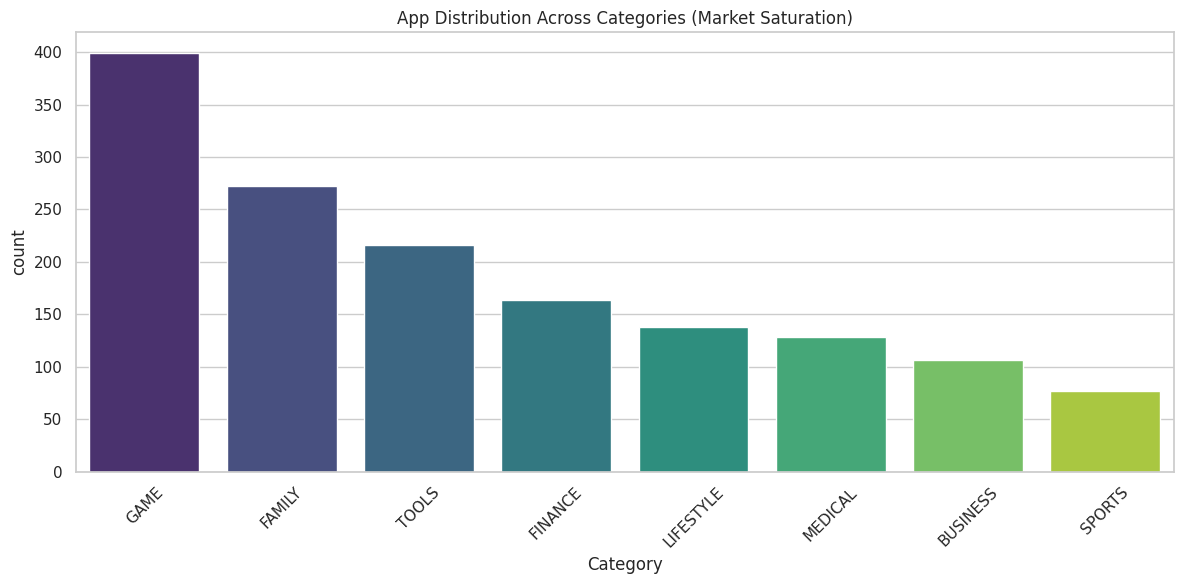

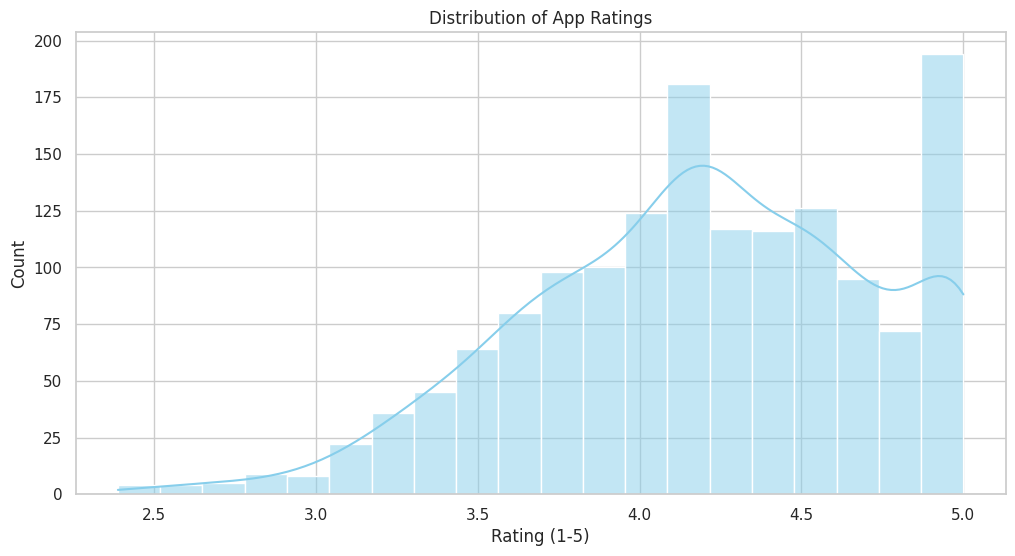


--- Average Rating by Category ---
 Category   Rating
   SPORTS 4.296585
  FINANCE 4.211483
    TOOLS 4.206755
LIFESTYLE 4.206187
  MEDICAL 4.183353
   FAMILY 4.180954
 BUSINESS 4.177728
     GAME 4.164309


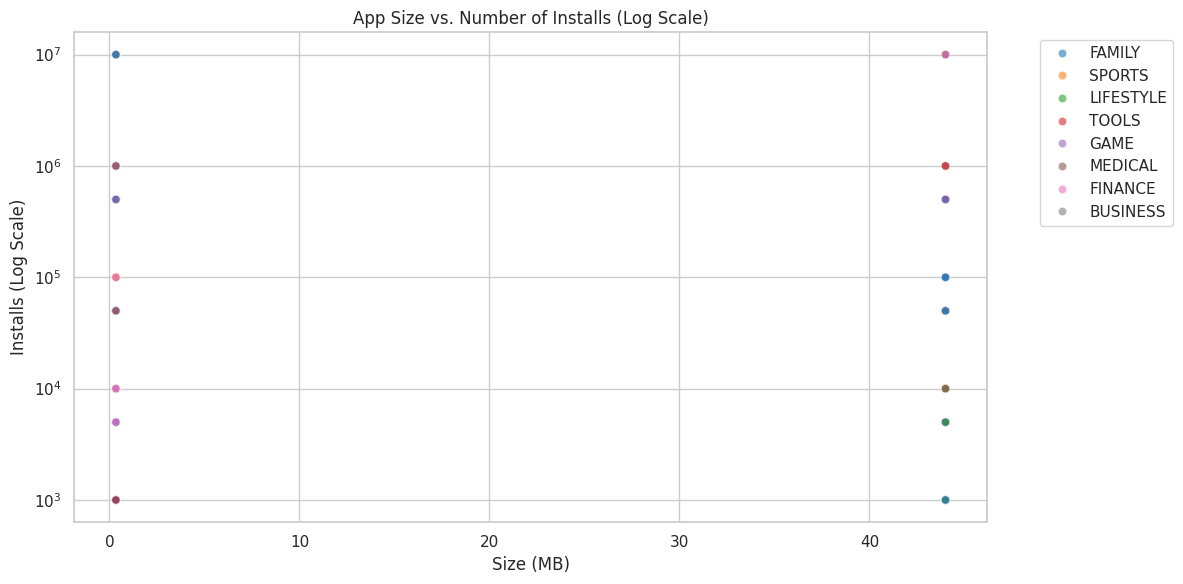


--- Paid vs Free App Distribution ---
Type
Free    89.2
Paid    10.8
Name: proportion, dtype: float64

--- Estimated Revenue by Category ---
 Category  Estimated_Revenue
    TOOLS        132386170.0
     GAME         79225810.0
 BUSINESS         50048500.0
  FINANCE         19948290.0
   FAMILY         19130520.0
  MEDICAL          5571840.0
LIFESTYLE          2314820.0
   SPORTS            61780.0

--- Sentiment Percentage by Category ---
Sentiment   Negative    Neutral   Positive
Category                                  
BUSINESS   12.500000  31.500000  56.000000
FAMILY     13.138686  36.496350  50.364964
FINANCE    11.146497  38.535032  50.318471
GAME       11.822660  36.576355  51.600985
LIFESTYLE   7.299270  35.401460  57.299270
MEDICAL    15.189873  35.021097  49.789030
SPORTS     17.293233  33.834586  48.872180
TOOLS      14.218009  38.625592  47.156398


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# VADER Sentiment Analysis के लिए (यदि इंस्टॉल न हो तो: pip install vaderSentiment)
!pip install vaderSentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# प्लॉट्स की स्टाइलिंग
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# रैंडम सीड सेट करना ताकि परिणाम हर बार समान रहें
np.random.seed(42)
n_apps = 1500
n_reviews = 3000


categories = ['GAME', 'FAMILY', 'TOOLS', 'FINANCE', 'LIFESTYLE', 'MEDICAL', 'BUSINESS', 'SPORTS']
app_names = [f"App_{i}" for i in range(n_apps)]

apps_data = {
    'App': app_names,
    'Category': np.random.choice(categories, size=n_apps, p=[0.25, 0.20, 0.15, 0.10, 0.10, 0.08, 0.07, 0.05]),
    'Rating': np.clip(np.random.normal(loc=4.2, scale=0.6, size=n_apps), 1.0, 5.0),
    'Reviews': np.random.randint(10, 500000, size=n_apps).astype(str), # स्ट्रिंग फॉर्मेट (गंदा डेटा)
    'Size': np.random.choice([f"{np.random.randint(5, 95)}M", f"{np.random.randint(100, 900)}k", "Varies with device"], size=n_apps),
    'Installs': np.random.choice(['1,000+', '5,000+', '10,000+', '50,000+', '100,000+', '500,000+', '1,000,000+', '10,000,000+'], size=n_apps),
    'Type': np.random.choice(['Free', 'Paid'], size=n_apps, p=[0.90, 0.10]),
    'Price': np.random.choice(['0', '$0.99', '$2.99', '$4.99', '$9.99', '$14.99'], size=n_apps, p=[0.90, 0.04, 0.03, 0.01, 0.01, 0.01])
}


df_apps = pd.DataFrame(apps_data)
df_apps.loc[df_apps.sample(frac=0.03).index, 'Rating'] = np.nan # Null values
df_apps = pd.concat([df_apps, df_apps.sample(n=20)]) # Duplicates

# सिमुलेटेड यूजर रिव्यूज डेटा
review_samples = [
    "Amazing app, love the UI and features!", "Very useful and saves a lot of time.",
    "Too many ads, completely uninstalled.", "It keeps crashing on my device.",
    "Decent app but needs improvements.", "Worst customer support ever.",
    "Average performance, nothing extraordinary.", "Superb! Highly recommended to everyone."
]

reviews_data = {
    'App': np.random.choice(app_names, size=n_reviews),
    'Translated_Review': np.random.choice(review_samples, size=n_reviews)
}
df_reviews = pd.DataFrame(reviews_data)
df_reviews.loc[df_reviews.sample(frac=0.02).index, 'Translated_Review'] = np.nan


print("--- Data Cleaning Pipeline Started ---")

# A. ऐप्स डेटा क्लीनिंग
df_apps.drop_duplicates(subset=['App'], inplace=True)
df_apps['Rating'] = df_apps['Rating'].fillna(df_apps['Rating'].median())

# Installs क्लीनिंग: ',' और '+' हटाकर इंटीजर में बदलना
df_apps['Installs'] = df_apps['Installs'].str.replace(',', '').str.replace('+', '', regex=False).astype(int)

# Price क्लीनिंग: '$' हटाकर फ्लोट में बदलना
df_apps['Price'] = df_apps['Price'].str.replace('$', '', regex=False).astype(float)

# Reviews क्लीनिंग: इंटीजर में बदलना
df_apps['Reviews'] = df_apps['Reviews'].astype(int)

# Size क्लीनिंग: मेगाबाइट (M) में बदलना, 'k' को कन्वर्ट करना और 'Varies with device' को मीडियन असाइन करना
def clean_size(size_str):
    if 'M' in size_str:
        return float(size_str.replace('M', ''))
    elif 'k' in size_str:
        return float(size_str.replace('k', '')) / 1024
    else:
        return np.nan

df_apps['Size_MB'] = df_apps['Size'].apply(clean_size)
df_apps['Size_MB'] = df_apps['Size_MB'].fillna(df_apps['Size_MB'].median())

# B. रिव्यूज डेटा क्लीनिंग
df_reviews.dropna(subset=['Translated_Review'], inplace=True)

print("Apps Data Shape after cleaning:", df_apps.shape)
print("Reviews Data Shape after cleaning:", df_reviews.shape)

plt.figure()
sns.countplot(data=df_apps, x='Category', order=df_apps['Category'].value_counts().index, palette='viridis')
plt.title('App Distribution Across Categories (Market Saturation)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Ratings Distribution (Histogram)
plt.figure()
sns.histplot(df_apps['Rating'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of App Ratings')
plt.xlabel('Rating (1-5)')
plt.show()

# Average Rating by Category
avg_rating = df_apps.groupby('Category')['Rating'].mean().sort_values(ascending=False).reset_index()
print("\n--- Average Rating by Category ---")
print(avg_rating.to_string(index=False))


plt.figure()
sns.scatterplot(data=df_apps, x='Size_MB', y='Installs', hue='Category', alpha=0.6, palette='tab10')
plt.yscale('log')
plt.title('App Size vs. Number of Installs (Log Scale)')
plt.xlabel('Size (MB)')
plt.ylabel('Installs (Log Scale)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Pricing Distribution (Paid vs Free Summary)
print("\n--- Paid vs Free App Distribution ---")
print(df_apps['Type'].value_counts(normalize=True) * 100)

# Revenue Estimate by Category (Estimated Revenue = Installs * Price)
df_apps['Estimated_Revenue'] = df_apps['Installs'] * df_apps['Price']
revenue_summary = df_apps.groupby('Category')['Estimated_Revenue'].sum().sort_values(ascending=False).reset_index()
print("\n--- Estimated Revenue by Category ---")
print(revenue_summary.to_string(index=False))


analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_reviews['Sentiment'] = df_reviews['Translated_Review'].apply(get_vader_sentiment)

# ऐप्स के साथ रिव्यूज को मर्ज (Merge) करना ताकि कैटगरी वाइस सेंटीमेंट मिल सके
df_merged = pd.merge(df_reviews, df_apps[['App', 'Category']], on='App', how='inner')

# Sentiment by Category Table
sentiment_category = pd.crosstab(df_merged['Category'], df_merged['Sentiment'], normalize='index') * 100
print("\n--- Sentiment Percentage by Category ---")
print(sentiment_category)


fig = px.scatter(df_apps,
                 x="Rating",
                 y="Installs",
                 size="Reviews",
                 color="Category",
                 hover_name="App",
                 log_y=True,
                 title="Interactive App Performance: Rating vs Installs (Bubble Size = Reviews)")
fig.show()
